# GenerativeTerrain — Terrain Generation Pipeline

This notebook is a **thin driver**: every heavy operation lives in the
`gt_terrain` package (`ml/gt_terrain/`), which is unit-tested and importable. The
notebook's job is to narrate the pipeline and show results.

## Why the old approach generated poorly

The previous models conditioned each voxel prediction on the **block IDs of its
six neighbours**, plus `Is_Surface` and `Light_Level`. All of those describe the
terrain *being generated* — so the model learned the trivial task *"fill this
hole given the blocks around it"* and never learned to generate anything. At
generation time those neighbours don't exist, so the model was fed zeros and
produced garbage.

**The fix is conceptual, not architectural.** A terrain generator may only
condition on what exists *before* terrain does:

* **position** (especially height `y`),
* the **chunk biome**,
* and — for variety — a **latent noise vector `z`**.

## What we build here

1. A correct, leakage-free data pipeline (`gt_terrain.data`).
2. A **deterministic baseline** that conditions on `(position, biome)` — it sets
   an accuracy floor and proves the pipeline (`BaselineVoxelNet`).
3. A **conditional VAE** that adds latent `z`, so sampling different `z` gives
   different terrain (`ConditionalTerrainVAE`).
4. Evaluation focused on **terrain plausibility** (vertical block profiles),
   plus ONNX export for the Java plugin.

In [1]:
# --- Make the gt_terrain package importable regardless of where Jupyter started.
import sys
from pathlib import Path

ML_DIR = Path.cwd()
while ML_DIR.name != "ml" and ML_DIR != ML_DIR.parent:
    ML_DIR = ML_DIR.parent
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

from gt_terrain.config import Config
from gt_terrain.blocks import BlockGrouping
from gt_terrain import data, train, evaluate, generate, export

# Standard config picks GPU automatically. For a quick CPU dry-run use:
#   cfg = Config.tiny()
cfg = Config()
print("device:", cfg.device)
print("data_dir:", cfg.data_dir)
print("artifact_dir:", cfg.artifact_dir)

device: cuda
data_dir: C:\Users\cathe\Desktop\Plugins\Server\block_dataset
artifact_dir: C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\ml\artifacts


## Step 1 — Data

Each CSV is one full chunk (16 × 384 × 16 voxels). We read **only** `x, y, z`,
`ChunkBiome`, and `Block_ID`; the leakage columns are never touched (a unit test
enforces this). Block names are collapsed into 27 semantic groups, and the whole
dataset is gridded into one in-memory array (~45 MB) — no per-chunk `.pt` files.

In [2]:
grouping = BlockGrouping()
biome_encoder = data.BiomeEncoder.from_csvs(data.list_csv_files(cfg))
grids, biome_ids = data.build_dataset(cfg, grouping, biome_encoder)

print(f"chunks: {grids.shape[0]}   grid shape per chunk: {grids.shape[1:]}")
print(f"block groups (classes): {grouping.num_classes}")
print(f"biomes: {biome_encoder.num_biomes} -> {biome_encoder.names}")

class_weights = data.compute_class_weights(grids, grouping.num_classes)
print("class-weight range:", round(float(class_weights.min()), 3),
      "to", round(float(class_weights.max()), 3))

chunks: 230   grid shape per chunk: (16, 384, 16)
block groups (classes): 27
biomes: 21 -> ['BADLANDS', 'BEACH', 'BIRCH_FOREST', 'CHERRY_GROVE', 'DARK_FOREST', 'FOREST', 'JUNGLE', 'LUKEWARM_OCEAN', 'OLD_GROWTH_BIRCH_FOREST', 'OLD_GROWTH_PINE_TAIGA', 'OLD_GROWTH_SPRUCE_TAIGA', 'PLAINS', 'RIVER', 'SAVANNA', 'SPARSE_JUNGLE', 'STONY_SHORE', 'SWAMP', 'TAIGA', 'WARM_OCEAN', 'WINDSWEPT_FOREST', 'WOODED_BADLANDS']
class-weight range: 0.262 to 1.068


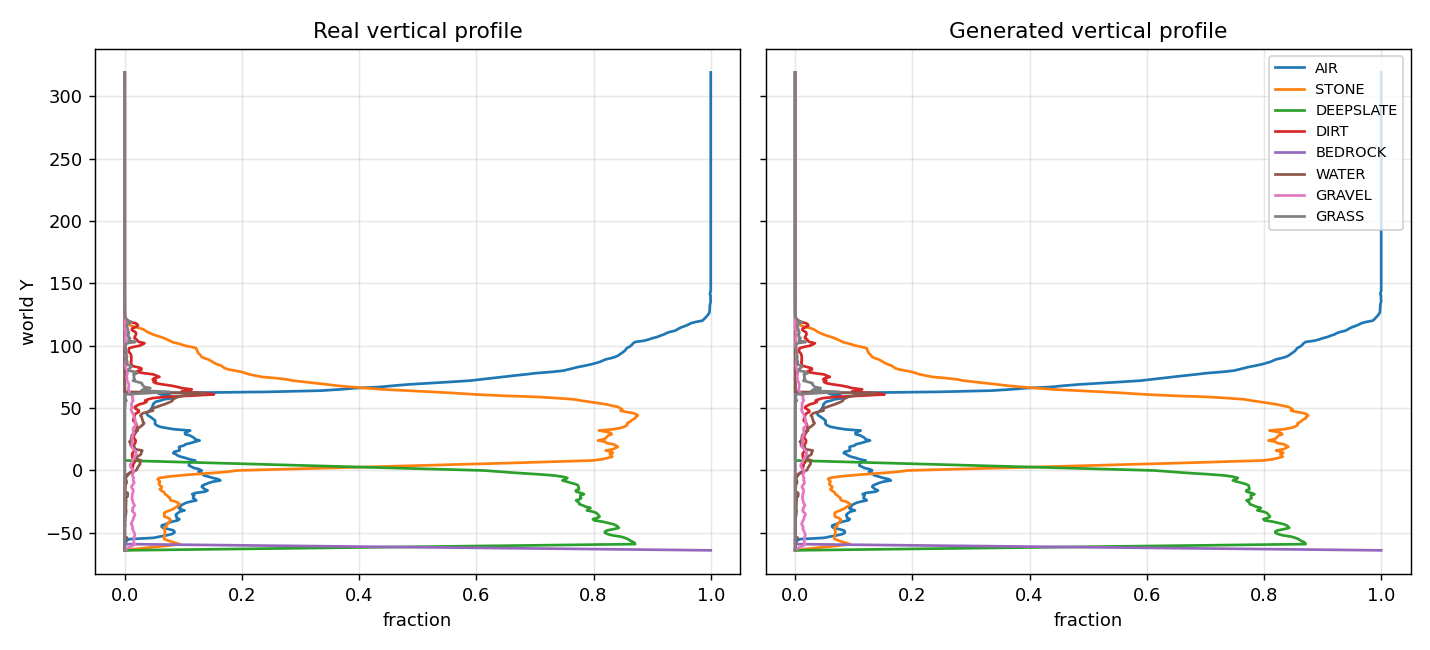

In [3]:
# Sanity check: the average vertical profile of the REAL data should look like
# terrain (bedrock floor, stone body, a thin surface band, air on top).
evaluate.plot_vertical_profiles(
    grids, grids, grouping, cfg, cfg.artifact_dir / "real_profile.png"
)
from IPython.display import Image
Image(str(cfg.artifact_dir / "real_profile.png"))

## Step 2 — Baseline (deterministic)

`BaselineVoxelNet` maps `(position, biome) → block-group logits`. Because it has
no source of randomness, it can only learn the *average* terrain for a biome:
expect smooth, layered output (correct block-by-height, but no hills, caves, or
trees). That is exactly the point — it gives us a number to beat and confirms the
plumbing end to end.

In [4]:
baseline, baseline_hist = train.train_baseline(
    cfg, grids, biome_ids, class_weights, grouping.num_classes, biome_encoder.num_biomes
)
evaluate.plot_training_curves(baseline_hist, cfg.artifact_dir / "baseline_curves.png", "Baseline")

_, _, test_loader = train.make_loaders(grids, biome_ids, cfg)
acc = evaluate.baseline_accuracy(baseline, test_loader, cfg)
print("baseline test accuracy:", round(acc["overall"], 4))
print("per-group accuracy (non-empty groups):")
for cid, a in acc["per_group"].items():
    if a == a:  # skip NaN (group absent in test set)
        print(f"  {grouping.idx_to_group[cid]:14s} {a:.3f}")

baseline e1 train:   0%|          | 0/21 [00:00<?, ?it/s]

[baseline] epoch 1 train 2.6675 val 2.3672


baseline e2 train:   0%|          | 0/21 [00:00<?, ?it/s]

[baseline] epoch 2 train 2.2335 val 2.1134


baseline e3 train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[baseline] epoch 164 train 0.5563 val 0.5747


baseline e165 train:   0%|          | 0/21 [00:00<?, ?it/s]

[baseline] epoch 165 train 0.5542 val 0.5666
[baseline] early stop at epoch 165


C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\ml\gt_terrain\train.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

baseline test accuracy: 0.9031
per-group accuracy (non-empty groups):
  AIR            0.948
  STONE          0.836
  DEEPSLATE      0.956
  DIRT           0.073
  GRASS          0.000
  SAND           0.683
  GRAVEL         0.000
  CLAY           0.000
  WATER          0.095
  LAVA           0.172
  BEDROCK        0.927
  COAL_ORE       0.000
  IRON_ORE       0.000
  COPPER_ORE     0.000
  GOLD_ORE       0.000
  REDSTONE_ORE   0.000
  LAPIS_ORE      0.000
  DIAMOND_ORE    0.000
  EMERALD_ORE    0.000
  OAK_WOOD       0.000
  SPRUCE_WOOD    0.000
  BIRCH_WOOD     0.000
  JUNGLE_WOOD    0.000
  DARK_OAK_WOOD  0.000
  VEGETATION     0.000
  MISC           0.000


## Step 3 — Conditional VAE (the generator)

The VAE adds a latent `z`: an encoder compresses each real chunk into `z`, and
the decoder reconstructs it from `z + biome + position`. Sampling `z ~ N(0, I)`
at generation time is what produces *varied* terrain.

With only ~230 chunks today, two stabilisers (built into `train_vae`) keep the
model from ignoring `z`: **KL annealing** and **free bits**. As you collect more
data, raise `cfg.latent_dim`, `cfg.base_channels`, and `cfg.epochs`.

vae e1 train:   0%|          | 0/21 [00:00<?, ?it/s]

[vae] epoch 1 beta 0.050 train 4.1787 val 3.9129


vae e2 train:   0%|          | 0/21 [00:00<?, ?it/s]

[vae] epoch 2 beta 0.100 train 5.3975 val 5.2777


vae e3 train:   0%|          | 0/21 [00:00<?, ?it/s]

...

vae e20 train:   0%|          | 0/21 [00:00<?, ?it/s]

[vae] epoch 20 beta 1.000 train 32.8631 val 32.8542


vae e21 train:   0%|          | 0/21 [00:00<?, ?it/s]

[vae] epoch 21 beta 1.000 train 32.8382 val 32.8794
[vae] early stop at epoch 21


C:\Users\cathe\Desktop\Plugins\GenerativeTerrain\GenerativeTerrain\ml\gt_terrain\train.py:205: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

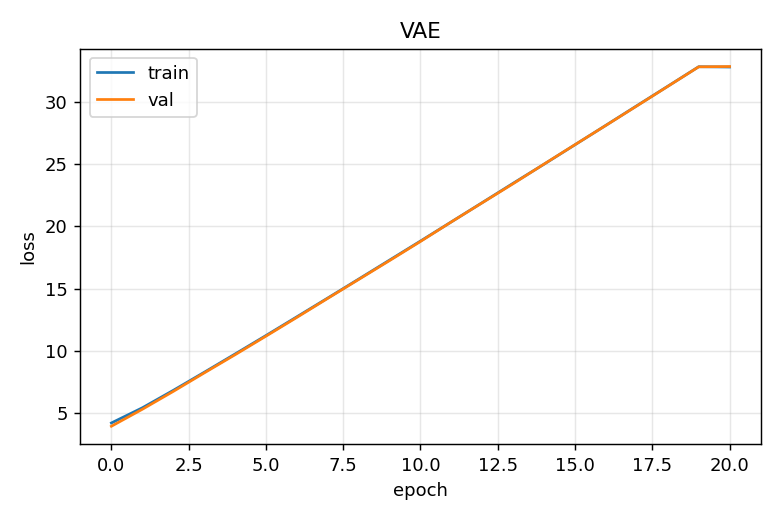

In [5]:
vae, vae_hist = train.train_vae(
    cfg, grids, biome_ids, class_weights, grouping.num_classes, biome_encoder.num_biomes
)
evaluate.plot_training_curves(vae_hist, cfg.artifact_dir / "vae_curves.png", "VAE")
Image(str(cfg.artifact_dir / "vae_curves.png"))

## Step 4 — Generate & evaluate

We sample several chunks for one biome and check two things:

* **diversity** — how much samples differ (0.0 would mean posterior collapse:
  every sample identical);
* **vertical profile** — generated vs real. The closer the generated profile is
  to the real one, the more plausible the terrain.

biome: BADLANDS
sample diversity: 0.0


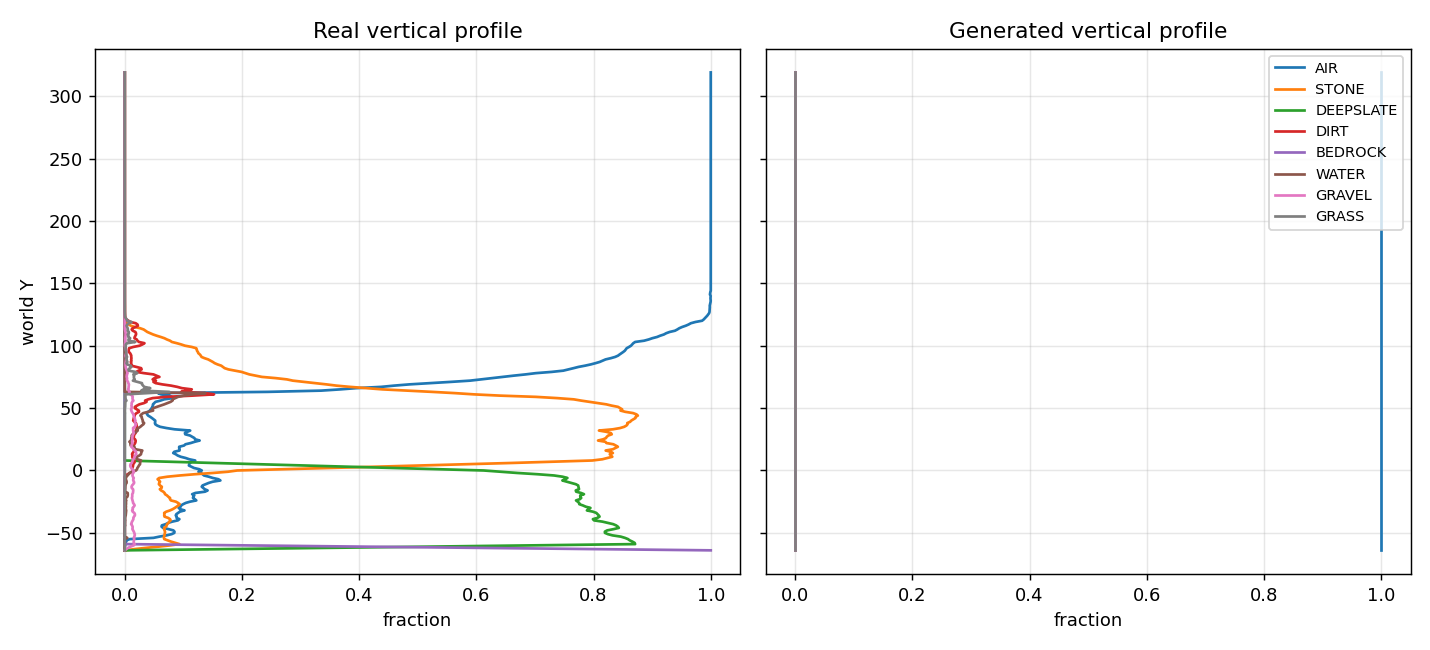

In [6]:
biome_name = biome_encoder.names[0]
biome_id = biome_encoder.transform(biome_name)
samples = generate.sample_grids(vae, biome_id, n=6, config=cfg)

print(f"biome: {biome_name}")
print("sample diversity:", round(evaluate.sample_diversity(samples), 4))

evaluate.plot_vertical_profiles(
    grids, samples, grouping, cfg, cfg.artifact_dir / "profiles.png"
)
Image(str(cfg.artifact_dir / "profiles.png"))

In [7]:
# Write one sample to a block-name CSV you can inspect (same schema the plugin uses).
df = generate.grid_to_csv(samples[0], grouping, cfg, cfg.artifact_dir / "generated_chunk_sample.csv")
df["Block_ID"].value_counts().head(12)

Block_ID
AIR    98304
Name: count, dtype: int64

## Step 5 — Export for the Java plugin

Export the **decoder only** to ONNX (`(z, biome_id) → logits`) and write the two
JSON mappings the plugin reads. Copy all three into your server's
`plugins/GenerativeTerrain/` folder.

In [8]:
onnx_path = export.export_decoder_onnx(vae, cfg)
group_map, biome_map = export.write_mappings(grouping, biome_encoder, cfg)
out_shape = export.verify_onnx(onnx_path, cfg, biome_encoder.num_biomes)

print("ONNX decoder :", onnx_path)
print("output shape :", out_shape, "(expected (1, 27, 16, 384, 16))")
print("group mapping:", group_map)
print("biome mapping:", biome_map)
print("\nCopy these into: <server>/plugins/GenerativeTerrain/")

ModuleNotFoundError: No module named 'onnxruntime'

## Where to go next

* **More data** is the highest-leverage change — the VAE is data-hungry and we
  currently have ~230 chunks. Export more biomes/worlds with `/grabchunkdata`.
* **Scale the model** once data grows: larger `latent_dim`, `base_channels`,
  `epochs`; consider per-biome `beta` tuning.
* **Spatial continuity across chunks** is a known limitation (each chunk is
  generated independently). A future step is to condition on neighbouring
  *generated* chunk edges — legitimately, since by then they exist.